Part 1: Iris Dataset


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original Model Test Accuracy: 0.90
Modified Model Test Accuracy: 0.93


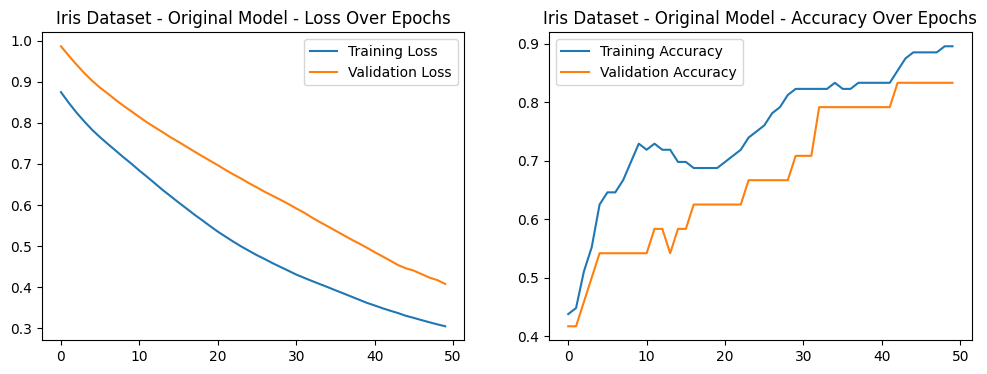

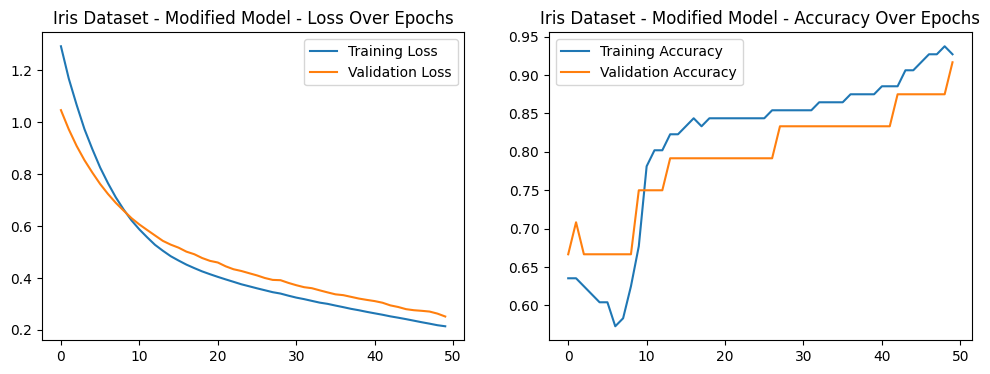


Part 2: Wine Dataset


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Wine Dataset Test Accuracy: 1.00


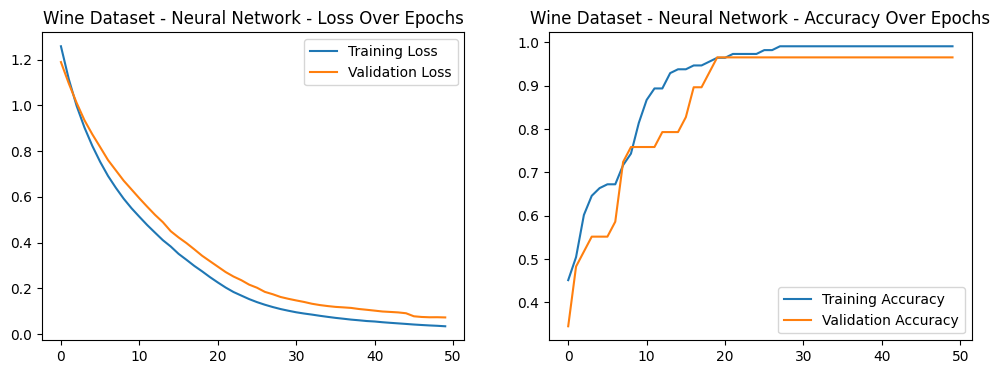

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


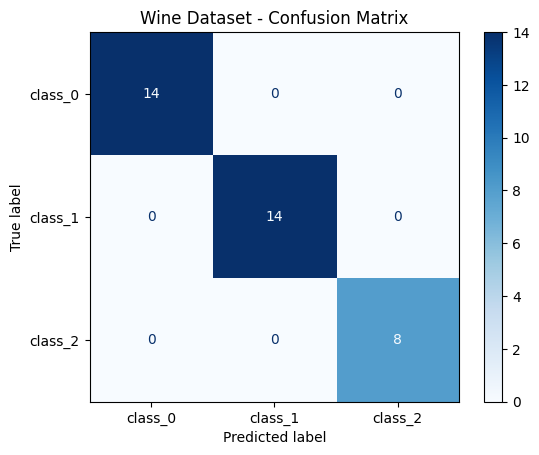

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Helper function to plot training history
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title(f'{title} - Loss Over Epochs')

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy Over Epochs')
    plt.show()

# Helper function to display confusion matrix
def plot_confusion_matrix(y_true, y_pred, target_names, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# ====================
# Part 1: Iris Dataset
# ====================
print("Part 1: Iris Dataset")
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# One-hot encode the target labels
encoder = OneHotEncoder(sparse_output=False)
y_iris = encoder.fit_transform(y_iris.reshape(-1, 1))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Original Model
model_original = Sequential([
    Dense(8, activation='relu', input_shape=(X_iris.shape[1],)),
    Dense(3, activation='softmax')
])

model_original.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_original = model_original.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Modified Model
model_modified = Sequential([
    Dense(8, activation='relu', input_shape=(X_iris.shape[1],)),
    Dense(16, activation='relu'),  # Added layer
    Dense(3, activation='softmax')
])

model_modified.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_modified = model_modified.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate Models
original_test_loss, original_test_accuracy = model_original.evaluate(X_test, y_test, verbose=0)
modified_test_loss, modified_test_accuracy = model_modified.evaluate(X_test, y_test, verbose=0)

print(f"Original Model Test Accuracy: {original_test_accuracy:.2f}")
print(f"Modified Model Test Accuracy: {modified_test_accuracy:.2f}")

# Plot results
plot_history(history_original, "Iris Dataset - Original Model")
plot_history(history_modified, "Iris Dataset - Modified Model")

# ====================
# Part 2: Wine Dataset
# ====================
print("\nPart 2: Wine Dataset")
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# One-hot encode the target labels
y_wine = encoder.fit_transform(y_wine.reshape(-1, 1))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize features
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Model for Wine Dataset
model_wine = Sequential([
    Dense(8, activation='relu', input_shape=(X_wine.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_wine.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_wine = model_wine.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate Model
wine_test_loss, wine_test_accuracy = model_wine.evaluate(X_test, y_test, verbose=0)
print(f"Wine Dataset Test Accuracy: {wine_test_accuracy:.2f}")

# Plot training history
plot_history(history_wine, "Wine Dataset - Neural Network")

# Confusion Matrix
y_pred = model_wine.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

plot_confusion_matrix(y_true_classes, y_pred_classes, wine.target_names, "Wine Dataset - Confusion Matrix")

